# Position Matters: Statistical Profiles Across the PLL - Team Analysis
## The Analysis

The next analytical goal focuses on each team in the PLL. We want to determine which player statistics have the greatest impact on winning games. 

# Approach
*Goal*: Determine which player statistics have the strongest influence on the team's ability to win games.

*Step 1*<br>
The features we will be analyzing for importance will be limited to avoid redundancy. We will look at the importance of *Team Shooting Percentage*, *Team Faceoff Percentage*, *Team Save Percentage*, *Team Caused Turnovers*, and *Team Groundballs*. This provides one statistic for each of the major positions (attack, faceoff, goalie, defense, midfielder).

*Step 2*<br>
Check the correlation between features to ensure they are approximately independent. This prevents bias in the later model.

*Step 3*<br>
Determine feature correlation to wins using simple correlation model.

*Step 4*<br>
Build Random Forest model for more insightful analysis (A linear regression model was considered, but it assumes a linear correlation which is not necessarily true).

*Step 5*<br>
Visualize the results.

**Important Analysis Limitation**: There are only eight teams in the PLL, which is a very limited sample size to work with. This could introduce potential bias.

In [1]:
#import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scipy
import scipy
import scipy.stats as stats
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestRegressor 

### Import the dataset

In [2]:
#import the data
team_data=pd.read_csv("pll-team-from-player-stats-clean.csv")
team_data

,Team,Team Points,Team Total Goals,Team One Point Goals,Team Two Point Goals,Team Assists,Team Shots,Team Two Points Shots,Team SOG,Team Two Point SOG,...,Team Shot Pct,Team SOG Pct,Team Faceoff Pct,Team Save Pct,Team Clean Save Pct,Game Wins,Game Losses,Scores,Scores Against,Score Differential
0,Archers,152,92,86,6,54,353,51,219,29,...,0.260623,0.620397,0.316017,0.591093,0.315068,4,6,98,111,-13
1,Atlas,215,129,122,7,79,427,44,268,21,...,0.302108,0.627635,0.562278,0.571429,0.401316,7,3,137,120,17
2,Cannons,188,113,101,12,63,412,71,256,41,...,0.274272,0.621359,0.422535,0.500000,0.421053,4,6,127,138,-11
3,Chaos,161,103,96,7,51,412,53,254,33,...,0.250000,0.616505,0.501946,0.574627,0.396104,5,5,110,125,-15
4,Outlaws,191,121,109,12,58,454,70,282,29,...,0.266520,0.621145,0.507634,0.547414,0.551181,7,3,131,113,18
5,Redwoods,175,116,106,10,49,446,75,279,40,...,0.260090,0.625561,0.568841,0.495833,0.319328,5,5,126,130,-4
6,Waterdogs,183,118,112,6,59,422,54,278,27,...,0.279621,0.658768,0.492537,0.500000,0.348214,4,6,124,127,-3
7,Whipsnakes,170,111,105,6,53,410,36,266,19,...,0.270732,0.648780,0.572549,0.539474,0.398374,4,6,119,108,11


### Check correlation between features
Determine if features have a high correlation between one another. They must have low correlation to one another in order to yield an insightful model for the feature importance analysis. We flag values with a correlation above 0.6.

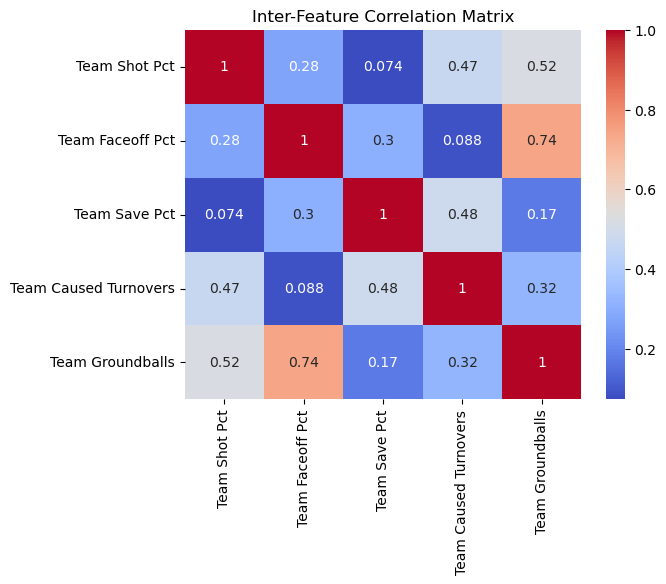

In [3]:
#define the features we are looking at
team_features=["Team Shot Pct", "Team Faceoff Pct", "Team Save Pct", "Team Caused Turnovers", "Team Groundballs"]

#create correlation matrix
interfeature_corr = (team_data[team_features].corr()).abs() #take absolute value of correlation, so values are all between 0 and 1

#plot as heatmap for interpretation
sns.heatmap(interfeature_corr, cmap='coolwarm', annot=True)
plt.title("Inter-Feature Correlation Matrix")
plt.show()

Faceoff Percentage and Groundballs have a correlation of 0.74, which is significantly above the threshold of 0.6 set earlier. According to the positional analysis, this is a reasonable correlation because faceoff players have a high number of groundballs as a part of their "clean faceoff" abilities. For this analysis, we will remove Team Groundballs from the list of features. 

In [4]:
#remove team groundballs from feature list
team_features.remove("Team Groundballs")

print(team_features)

['Team Shot Pct', 'Team Faceoff Pct', 'Team Save Pct', 'Team Caused Turnovers']


### Simple feature correlation to wins
We utilize a simple correlation model to establish a baseline for the more complex model. It also ensures this analysis is reasonable and has reasonably limited bias.

In [5]:
#do basic correlation between features we had and game wins
wins_basic_corr = team_data[team_features+["Game Wins"]].corr()

#pull out just the game wins column and sort it
wins_basic_corr_col = wins_basic_corr["Game Wins"].sort_values(ascending=False)
print(wins_basic_corr_col)
type(wins_basic_corr_col)

Game Wins                1.000000
Team Faceoff Pct         0.419724
Team Shot Pct            0.360067
Team Save Pct            0.309173
Team Caused Turnovers    0.257139
Name: Game Wins, dtype: float64


pandas.core.series.Series

In [6]:
#set up stats for a visual by dropping "Game Wins" correlation (1.0)
wins_basic_corr_col=wins_basic_corr["Game Wins"].drop("Game Wins")
#sort the values to be increasing
wins_basic_corr_col=wins_basic_corr_col.sort_values()

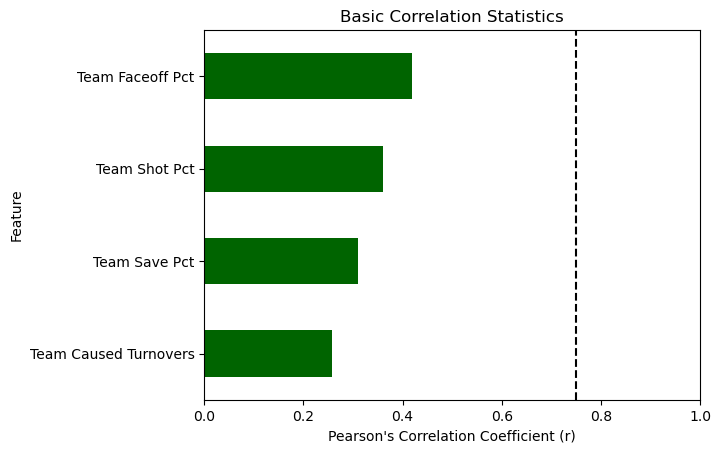

In [7]:
#visualize basic correlation
wins_basic_corr_col.plot(kind='barh', color='darkgreen')
plt.xlim(0,1)
plt.title("Basic Correlation Statistics")
plt.ylabel("Feature")
plt.xlabel("Pearson's Correlation Coefficient (r)")
plt.axvline(x=0.75, color='k', linestyle='--')
plt.show()

**Analysis** <br>
Faceoff Percentage is the statistic that has the highest correlation coefficient at 0.419. This indicates a moderate relationship between faceoff percentage and a team's ability to win. The Shooting Percentage and Save Percentage have correlation coefficients of 0.360 and 0.309 respectively, indicating a weak relationship. Caused turnovers has the least correlation coefficient (0.257) which indicates a very weak relationship. There are no statistics that indicate a strong relationship (above 0.75), likely due to the limited sample size (8 teams). This suggests that no stat individually drives winning in isolation and that further studies should incorporate data from multiple seasons to solidify the relationship.

### Random Forest Regression model
Despite the non-statistically significant results in the basic analysis, a more advanced model is created to validate those results. A Random Forest Regression model can test for nonlinear relationships that the basic test cannot account for.

In [8]:
#train-test set
X=team_data[team_features]
y=team_data["Game Wins"]

#establish and train model
model_pll = RandomForestRegressor(n_estimators=100,random_state=16)
model_pll.fit(X,y)

RandomForestRegressor(random_state=16)

In [9]:
#extract feature importances
pll_importances = model_pll.feature_importances_

feature_importance_df=pd.DataFrame({
    "Feature":X.columns, 
    "Importance":pll_importances}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                 Feature  Importance
0          Team Shot Pct    0.448268
1       Team Faceoff Pct    0.250621
2          Team Save Pct    0.189860
3  Team Caused Turnovers    0.111251


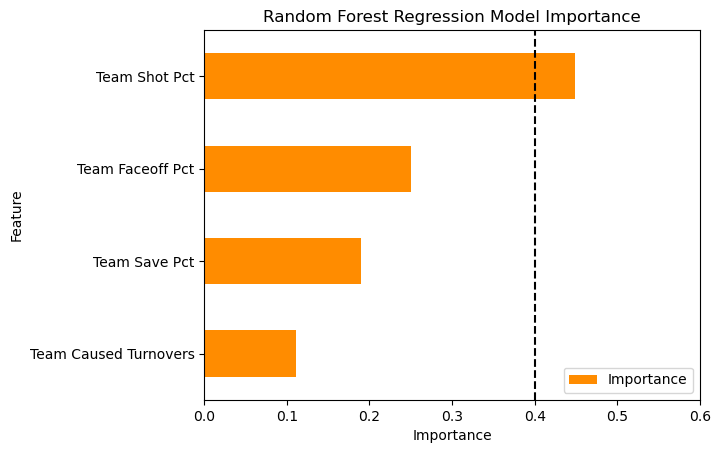

In [10]:
#visualization of importances
feature_importance_df=feature_importance_df.sort_values(by="Importance", ascending=True)
feature_importance_df.plot(kind='barh',x="Feature",y="Importance", color='darkorange')
plt.xlim(0,0.6)
plt.title("Random Forest Regression Model Importance")
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.axvline(x=0.4, color='k', linestyle='--')
plt.legend(loc='lower right')
plt.show()

**Analysis**<br>
*Quick Background*<br>
These 'importances' are Mean Decreases in Impurity. As a baseline, since we tested four features, they begin at 0.25 each. Then, as the model is trained, they adjust to reflect actual trends. A value over 0.4 is considered a feature of high importance because it accounts for 40% of all variance reduction.

*Meaning*<br>
Shooting percentage has an importance of 0.448, demonstrating that it is a feature of high importance. Teams should prioritize shooting accuracy when creating their rosters. Faceoff percentage has an importance of 0.251, which is slightly above the starting threshold. Therefore, it is considered a support feature that still affects a team's ability to win, but it is not as important as shooting percentage. Save percentage has an importance of 0.190, showing it is considered a weaker support feature that contributes to baseline team wins. Caused turnovers has an importance of 0.111, so it only impacts the very specific details of the wins/model. Overall, shooting accuracy should be the most important to a team when creating their roster. 

### Final team insights
- Shooting percentage and faceoff win percentage have the highest correlation with team wins, despite still being a statistically moderate relation.
- Teams should prioritize being well-rounded to improve their chances at winning. There was no strong correlation between any single statistic and winning, despite multiple models of various sophistications performing analysis.
- The small sample size (8 teams in one season) was a likely cause of this limited conclusion.